# Agrupamiento de Equipos por Estilo Tactico (K-Medias)

Reproduce la Seccion 4.2 del informe: K-Medias sobre los 9 atributos numericos de `team_attributes` (construccion de juego, creacion de oportunidades y comportamiento defensivo). Los registros con valores nulos se excluyen (489 snapshots). Seleccion de K con Davies-Bouldin + curva del codo, previo estandarizado z-score.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / ".git").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root / "src"))

import pandas as pd
from mineria.data_loader import load_table
from mineria.clustering import team_cluster_data, standardize, kmeans_scores, fit_kmeans, profile_means, closest_to_centroids
from mineria.plots import radar_profiles, elbowa_plot
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df, cols = team_cluster_data(load_table("Team_Attributes"))
print("Snapshots tacticos sin nulos:", len(df))
X = standardize(df, cols)

Snapshots tacticos sin nulos: 489


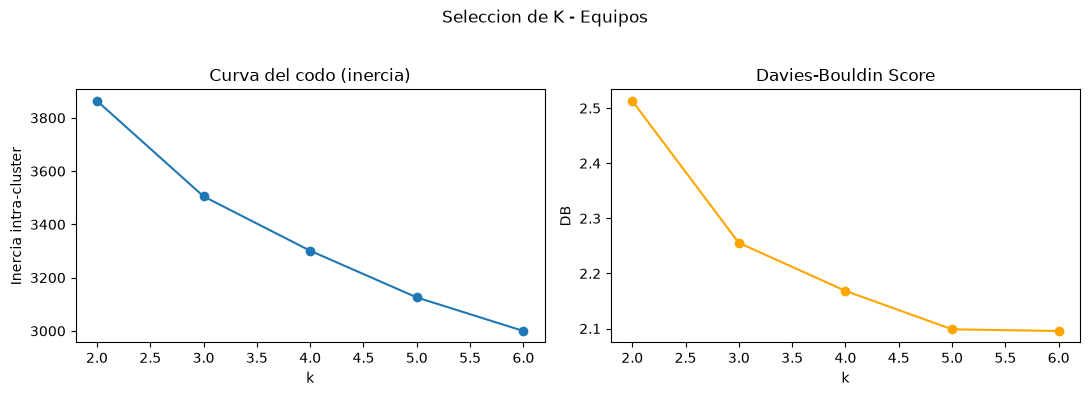

In [3]:
scores = kmeans_scores(X, range(2, 7))
scores.round(3)
elbowa_plot(scores, "Seleccion de K - Equipos");

In [4]:
km = fit_kmeans(X, 3)
df["cluster"] = km.labels_
df["cluster"].value_counts().sort_index()

cluster
0    137
1    186
2    166
Name: count, dtype: int64

In [5]:
profile_means(df, km, cols).round(1)

cluster,0,1,2
buildUpPlaySpeed,45.1,57.5,57.7
buildUpPlayDribbling,47.8,47.8,50.2
buildUpPlayPassing,41.3,53.6,51.3
chanceCreationPassing,46.3,51.8,58.6
chanceCreationCrossing,51.1,51.8,56.2
chanceCreationShooting,48.8,48.3,56.8
defencePressure,49.0,38.1,50.1
defenceAggression,50.4,43.6,52.4
defenceTeamWidth,54.3,47.8,53.6


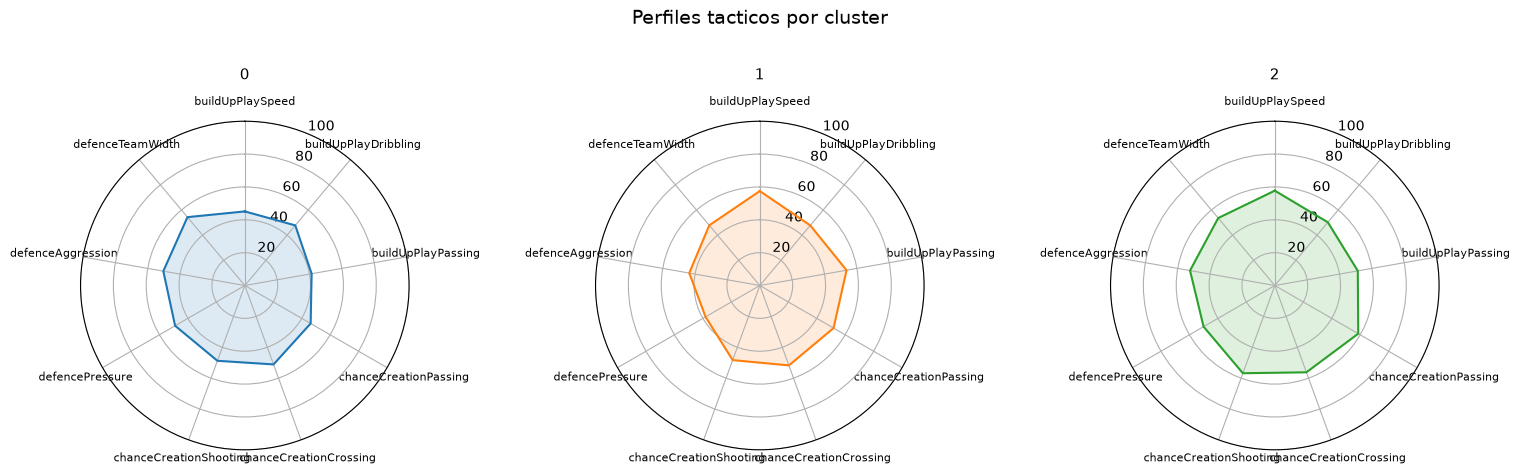

In [6]:
radar_profiles(profile_means(df, km, cols), "Perfiles tacticos por cluster");

In [7]:
representativos = closest_to_centroids(df, X, km)
team = load_table("Team")
representativos = representativos.merge(team[["team_api_id", "team_long_name"]], on="team_api_id", how="left")
representativos[["cluster", "team_long_name"]]

,cluster,team_long_name
0,0,Club Brugge KV
1,1,Sporting Charleroi
2,2,Real Sociedad


## Interpretacion

- **Conservador (n=137)**: velocidad de juego baja (45.1) y pases cortos (41.3), presion moderada (49.0). Priorizan no perder la pelota.
- **Contraataque (n=186)**: velocidad media-alta (57.5) con presion baja (38.1) y agresividad reducida (43.6). Bloque bajo con transiciones rapidas.
- **Ofensivo (n=166)**: maxima creacion de disparo (56.8), velocidad alta (57.7) y presion activa (50.1).

Los equipos mas proximos a cada centroide ratifican la coherencia semantica (p. ej. Brugge KV y Partick Thistle en el grupo conservador; Sporting Charleroi y AS Saint-Etienne en contraataque; Real Sociedad en el ofensivo).